# SeamlessM4T `<unk>` Mitigation Sensitivity Experiment

This notebook tests whether the Direct system's `<unk>` behaviour can be reduced by changing **only the decoding strategy**.

It does **not** overwrite the official 4,200-sample Direct results.

Four conditions are tested:

1. **Baseline greedy** — official decoding configuration.
2. **Greedy + block `<unk>`** — same decoding, but suppress the tokenizer's unknown-token ID.
3. **Beam-5** — deterministic beam search.
4. **Beam-5 + block `<unk>`** — beam search plus unknown-token suppression.

The default run uses a small balanced subset of originally affected clips. After that works, change `TEST_SCOPE` to `"all_affected"` to test all original `<unk>` rows.

Any improved configuration is a **post-hoc sensitivity analysis**, not a replacement for the official baseline.


## 1. Install and import libraries

The versions are chosen to match the recorded Direct run as closely as practical.


In [1]:
%pip install -q "transformers==4.57.6" sentencepiece pandas numpy matplotlib psutil huggingface_hub sacrebleu torch torchaudio soundfile librosa
%pip install -q torch==2.11.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu128
%pip install -q torchcodec==0.11


You should consider upgrading via the '/Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement torch==2.11.0 (from versions: none)
ERROR: No matching distribution found for torch==2.11.0
You should consider upgrading via the '/Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement torchcodec==0.11 (from versions: 0.0.0.dev0, 0.1.0, 0.1.1, 0.2.0, 0.2.1, 0.3.0, 0.4.0, 0.5, 0.6.0, 0.7.0)
ERROR: No matching distribution found for torchcodec==0.11
You should consider upgrading via the '/Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-rese

In [2]:
from pathlib import Path
from datetime import datetime, timezone
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu
import torch
import torchaudio
import transformers

from transformers import AutoProcessor, SeamlessM4Tv2ForSpeechToText

print("PyTorch:", torch.__version__)
print("Torchaudio:", torchaudio.__version__)
print("Transformers:", transformers.__version__)
print("SacreBLEU:", sacrebleu.__version__)
print("CUDA available:", torch.cuda.is_available())


/Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


PyTorch: 2.8.0
Torchaudio: 2.8.0
Transformers: 4.57.6
SacreBLEU: 2.6.0
CUDA available: False


## 2. Configuration

Start with the small test:

```python
TEST_SCOPE = "balanced_small"
SAMPLES_PER_ACCENT = 5
```

Then switch to:

```python
TEST_SCOPE = "all_affected"
```

to test every original Direct row containing `<unk>`.


In [3]:
SEED = 760

MODEL_ID = "facebook/seamless-m4t-v2-large"
MODEL_REVISION = "5f8cc790b19fc3f67a61c105133b20b34e3dcb76"
TARGET_LANGUAGE = "cmn"

TEST_SCOPE = "balanced_small"  # "balanced_small" or "all_affected"
SAMPLES_PER_ACCENT = 5

BASELINE_GENERATION = {
    "num_beams": 1,
    "do_sample": False,
    "max_new_tokens": 256,
}

EXPERIMENTS = {
    "baseline_greedy": {
        **BASELINE_GENERATION,
        "block_unk": False,
    },
    "greedy_block_unk": {
        **BASELINE_GENERATION,
        "block_unk": True,
    },
    "beam5": {
        "num_beams": 5,
        "do_sample": False,
        "max_new_tokens": 256,
        "block_unk": False,
    },
    "beam5_block_unk": {
        "num_beams": 5,
        "do_sample": False,
        "max_new_tokens": 256,
        "block_unk": True,
    },
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(json.dumps(EXPERIMENTS, indent=2))


{
  "baseline_greedy": {
    "num_beams": 1,
    "do_sample": false,
    "max_new_tokens": 256,
    "block_unk": false
  },
  "greedy_block_unk": {
    "num_beams": 1,
    "do_sample": false,
    "max_new_tokens": 256,
    "block_unk": true
  },
  "beam5": {
    "num_beams": 5,
    "do_sample": false,
    "max_new_tokens": 256,
    "block_unk": false
  },
  "beam5_block_unk": {
    "num_beams": 5,
    "do_sample": false,
    "max_new_tokens": 256,
    "block_unk": true
  }
}


## 3. Resolve project paths


In [4]:
def find_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd.parent]:
        if (candidate / "data").exists() and (candidate / "runs").exists():
            return candidate
    return cwd

PROJECT_ROOT = find_project_root()

prediction_candidates = [
    PROJECT_ROOT / "runs/direct_full_run_1788151795/direct_predictions.csv",
    PROJECT_ROOT / "runs/direct_run_1788151795/direct_predictions.csv",
]

DIRECT_PREDICTIONS_PATH = next(
    (p for p in prediction_candidates if p.is_file()),
    prediction_candidates[0],
)

AUDIO_DIR = PROJECT_ROOT / "data/final_sample/final_sample_audio"

OUTPUT_DIR = (
    PROJECT_ROOT
    / "runs"
    / f"direct_unk_sensitivity_{int(time.time())}"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)

if not DIRECT_PREDICTIONS_PATH.is_file():
    raise FileNotFoundError(
        f"Direct predictions not found: {DIRECT_PREDICTIONS_PATH}"
    )

if not AUDIO_DIR.is_dir():
    raise NotADirectoryError(
        f"Audio directory not found: {AUDIO_DIR}"
    )

print("Project root:", PROJECT_ROOT)
print("Official predictions:", DIRECT_PREDICTIONS_PATH)
print("Audio:", AUDIO_DIR)
print("Output:", OUTPUT_DIR)


Project root: /Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research
Official predictions: /Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/runs/direct_full_run_1788151795/direct_predictions.csv
Audio: /Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/data/final_sample/final_sample_audio
Output: /Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/runs/direct_unk_sensitivity_1789954497


## 4. Select originally affected clips


In [5]:
pred = pd.read_csv(DIRECT_PREDICTIONS_PATH)

required = {
    "id",
    "clip",
    "sentence",
    "primary_accent",
    "sample_id",
    "reference_translation_zh",
    "direct_translation",
}

missing = required - set(pred.columns)
if missing:
    raise KeyError(f"Missing required columns: {sorted(missing)}")

pred = pred.copy()

pred["original_has_unk"] = (
    pred["direct_translation"]
    .fillna("")
    .astype(str)
    .str.contains("<unk>", regex=False)
)

affected = pred[pred["original_has_unk"]].copy()

print("Official rows:", len(pred))
print("Originally affected rows:", len(affected))

if TEST_SCOPE == "balanced_small":
    parts = []

    for accent, group in affected.groupby("primary_accent", sort=True):
        n = min(SAMPLES_PER_ACCENT, len(group))
        parts.append(group.sample(n=n, random_state=SEED))

    test_df = (
        pd.concat(parts, ignore_index=True)
        .sort_values(["primary_accent", "id"])
        .reset_index(drop=True)
    )

elif TEST_SCOPE == "all_affected":
    test_df = affected.reset_index(drop=True)

else:
    raise ValueError(
        "TEST_SCOPE must be 'balanced_small' or 'all_affected'."
    )

print("Selected rows:", len(test_df))

display(
    test_df["primary_accent"]
    .value_counts()
    .rename("clips")
    .to_frame()
)

display(
    test_df[
        [
            "id",
            "primary_accent",
            "sentence",
            "reference_translation_zh",
            "direct_translation",
        ]
    ].head(20)
)


Official rows: 4200
Originally affected rows: 508
Selected rows: 35


,clips
primary_accent,
England English,5
Filipino,5
Hong Kong English,5
"India and South Asia (India, Pakistan, Sri Lanka)",5
Malaysian English,5
"Southern African (South Africa, Zimbabwe, Namibia)",5
United States English,5


,id,primary_accent,sentence,reference_translation_zh,direct_translation
0,sample_0090,England English,Restoration silver is characterized by embosse...,修复银的特点是压花图案表现的郁金香和自然的水果和树叶。,修复银的特点是<unk>花和自然的水果和叶子的雕刻图案.
1,sample_0221,England English,Who is the blonde girl with the red skirt?,那个穿红裙子的金发女孩是谁?,那个穿着红色<unk>子的金发女孩是谁?
2,sample_0235,England English,"When he saw Henderson in his garden, he called...",当他看见 Henderson 在他的花园里时，他隔着篱笆喊了一声，对方明白了他的意思。,"当他看到亨德森在他的花园,他叫过<unk>,并让自己理解."
3,sample_0282,England English,The hail pattered on the burnt brown grass.,冰雹拍打着烧焦的棕色草地。,冰雹在烧焦的棕色草地上<unk>.
4,sample_0441,England English,"Roll the dice, please.",请掷骰子。,"投<unk>子,请."
5,sample_0653,Filipino,"Grime, rust and residual particles polluted th...",尘垢、铁锈和残留的微粒污染了空气。,"污垢,<unk>和残留的粒子污染了空气."
6,sample_0731,Filipino,A little scrambling is required for access.,访问需要加一些扰码。,需要一点<unk>密才能进入.
7,sample_0826,Filipino,"The Englishman prodded him, and the boy asked ...",英国人戳了他一下，男孩就问她是谁治好了人们的病。,"这位英国人<unk>了他,男孩问她关于治愈人们疾病的人."
8,sample_0905,Filipino,"They walked in from the rain, all dishevelled ...",他们从雨中走了进来，衣冠不整，浑身湿透。,"他们从雨中走进来, 所有的<unk>乱和蒸汽."
9,sample_0965,Filipino,"You were looking squeamish this afternoon, he ...",他说着，你今天下午看起来很邋遢。,"他开始说,今天下午你看起来很<unk>."


## 5. Device and precision

For the closest comparison with the official run, use the same **Tesla T4 + FP16** environment.


In [6]:
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")
MODEL_DTYPE = torch.float16 if CUDA_AVAILABLE else torch.float32

GPU_NAME = (
    torch.cuda.get_device_name(0)
    if CUDA_AVAILABLE
    else None
)

print("Device:", DEVICE)
print("dtype:", MODEL_DTYPE)
print("GPU:", GPU_NAME)

if not CUDA_AVAILABLE:
    print(
        "WARNING: CPU inference will be much slower and is not "
        "numerically identical to the official T4 FP16 run."
    )


Device: cpu
dtype: torch.float32
GPU: None


## 6. Load the exact Direct model and processor


In [7]:
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    revision=MODEL_REVISION,
)

model = SeamlessM4Tv2ForSpeechToText.from_pretrained(
    MODEL_ID,
    revision=MODEL_REVISION,
    dtype=MODEL_DTYPE,
)

model.to(DEVICE)
model.eval()

MODEL_SAMPLE_RATE = int(
    getattr(processor.feature_extractor, "sampling_rate", 16000)
)

UNK_ID = processor.tokenizer.unk_token_id
UNK_TOKEN = processor.tokenizer.unk_token

print("Model:", MODEL_ID)
print("Revision:", MODEL_REVISION)
print("Sample rate:", MODEL_SAMPLE_RATE)
print("UNK token:", UNK_TOKEN)
print("UNK token ID:", UNK_ID)

if UNK_ID is None:
    raise ValueError("Tokenizer does not expose an unk_token_id.")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model: facebook/seamless-m4t-v2-large
Revision: 5f8cc790b19fc3f67a61c105133b20b34e3dcb76
Sample rate: 16000
UNK token: <unk>
UNK token ID: 1


## 7. Audio preprocessing helper

This mirrors the official Direct pipeline.


In [8]:
def load_audio_for_model(
    audio_path,
    target_sample_rate=MODEL_SAMPLE_RATE
):
    audio_path = Path(audio_path)

    if not audio_path.is_file():
        raise FileNotFoundError(
            f"Audio file not found: {audio_path}"
        )

    try:
        # Preferred path: same method as the original pipeline.
        waveform, source_sample_rate = torchaudio.load(
            str(audio_path)
        )

        waveform = waveform.mean(dim=0)

        if source_sample_rate != target_sample_rate:
            waveform = torchaudio.functional.resample(
                waveform,
                source_sample_rate,
                target_sample_rate,
            )

        waveform = (
            waveform
            .to(torch.float32)
            .contiguous()
        )

        loader_used = "torchaudio"

    except RuntimeError as exc:
        print(
            f"torchaudio could not decode {audio_path.name}. "
            "Falling back to librosa."
        )

        import librosa

        waveform_np, source_sample_rate = librosa.load(
            str(audio_path),
            sr=target_sample_rate,
            mono=True,
        )

        waveform = torch.from_numpy(
            waveform_np
        ).to(torch.float32)

        source_sample_rate = target_sample_rate
        loader_used = "librosa"

    duration_sec = (
        waveform.numel()
        / float(target_sample_rate)
    )

    if duration_sec <= 0:
        raise ValueError(
            f"Decoded audio is empty: {audio_path}"
        )

    return (
        waveform.cpu().numpy(),
        duration_sec,
    )

## 8. Generation helper

For the blocked conditions, the tokenizer's actual unknown-token ID is passed through `suppress_tokens`.

The generated token IDs are also inspected directly.


In [9]:
def synchronize_device():
    if CUDA_AVAILABLE:
        torch.cuda.synchronize()


def translate_one(audio_path, experiment_name, experiment_config):
    waveform, duration_sec = load_audio_for_model(audio_path)

    inputs = processor(
        audio=waveform,
        sampling_rate=MODEL_SAMPLE_RATE,
        return_tensors="pt",
    )

    model_inputs = {}

    for name, tensor in inputs.items():
        if torch.is_floating_point(tensor):
            model_inputs[name] = tensor.to(
                device=DEVICE,
                dtype=MODEL_DTYPE,
            )
        else:
            model_inputs[name] = tensor.to(DEVICE)

    generation_kwargs = {
        key: value
        for key, value in experiment_config.items()
        if key != "block_unk"
    }

    if experiment_config["block_unk"]:
        generation_kwargs["suppress_tokens"] = [UNK_ID]

    synchronize_device()
    start = time.perf_counter()

    with torch.inference_mode():
        generated = model.generate(
            **model_inputs,
            tgt_lang=TARGET_LANGUAGE,
            **generation_kwargs,
        )

    synchronize_device()
    runtime_sec = time.perf_counter() - start

    token_ids = generated[0]

    if token_ids.ndim > 1:
        token_ids = token_ids[0]

    token_ids_list = token_ids.detach().cpu().tolist()

    translation = processor.decode(
        token_ids_list,
        skip_special_tokens=True,
    ).strip()

    unk_id_count = sum(
        int(token_id == UNK_ID)
        for token_id in token_ids_list
    )

    return {
        "experiment": experiment_name,
        "translation": translation,
        "runtime_sec": runtime_sec,
        "audio_duration_sec": duration_sec,
        "generated_token_count": len(token_ids_list),
        "generated_unk_id_count": unk_id_count,
        "decoded_contains_literal_unk": "<unk>" in translation,
        "generated_token_ids": token_ids_list,
    }


## 9. Warm-up

Warm-up is excluded from experiment timings.


In [10]:
warmup_row = test_df.iloc[0]
warmup_audio = AUDIO_DIR / str(warmup_row["clip"])

if not warmup_audio.is_file():
    raise FileNotFoundError(
        f"Warm-up audio not found: {warmup_audio}"
    )

_ = translate_one(
    warmup_audio,
    "warmup",
    {
        **BASELINE_GENERATION,
        "block_unk": False,
    },
)

print("Warm-up complete.")


/Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


Warm-up complete.


## 10. Run all four sensitivity conditions

Every condition is run on exactly the same selected clips.


In [11]:
records = []

total_jobs = len(test_df) * len(EXPERIMENTS)
completed = 0

for _, row in test_df.iterrows():
    audio_path = AUDIO_DIR / str(row["clip"])

    if not audio_path.is_file():
        raise FileNotFoundError(
            f"Audio not found: {audio_path}"
        )

    for experiment_name, experiment_config in EXPERIMENTS.items():
        completed += 1

        print(
            f"[{completed}/{total_jobs}] "
            f"{row['id']} | {experiment_name}"
        )

        result = translate_one(
            audio_path,
            experiment_name,
            experiment_config,
        )

        records.append({
            "id": row["id"],
            "sample_id": row["sample_id"],
            "primary_accent": row["primary_accent"],
            "clip": row["clip"],
            "sentence": row["sentence"],
            "reference_translation_zh": row["reference_translation_zh"],
            "official_direct_translation": row["direct_translation"],
            **result,
        })

results = pd.DataFrame(records)

results.to_csv(
    OUTPUT_DIR / "unk_sensitivity_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Sensitivity inference complete.")
print("Rows:", len(results))


[1/140] sample_0090 | baseline_greedy
[2/140] sample_0090 | greedy_block_unk
[3/140] sample_0090 | beam5
[4/140] sample_0090 | beam5_block_unk
[5/140] sample_0221 | baseline_greedy
[6/140] sample_0221 | greedy_block_unk
[7/140] sample_0221 | beam5
[8/140] sample_0221 | beam5_block_unk
[9/140] sample_0235 | baseline_greedy
[10/140] sample_0235 | greedy_block_unk
[11/140] sample_0235 | beam5
[12/140] sample_0235 | beam5_block_unk
[13/140] sample_0282 | baseline_greedy
[14/140] sample_0282 | greedy_block_unk
[15/140] sample_0282 | beam5
[16/140] sample_0282 | beam5_block_unk
[17/140] sample_0441 | baseline_greedy
[18/140] sample_0441 | greedy_block_unk
[19/140] sample_0441 | beam5
[20/140] sample_0441 | beam5_block_unk
[21/140] sample_0653 | baseline_greedy
[22/140] sample_0653 | greedy_block_unk
[23/140] sample_0653 | beam5
[24/140] sample_0653 | beam5_block_unk
[25/140] sample_0731 | baseline_greedy
[26/140] sample_0731 | greedy_block_unk
[27/140] sample_0731 | beam5
[28/140] sample_073

## 11. Check baseline reproduction

Before trusting the sensitivity comparison, verify that the baseline condition reproduces the official saved Direct output.


In [12]:
baseline = results[
    results["experiment"] == "baseline_greedy"
].copy()

baseline["exactly_matches_official"] = (
    baseline["translation"].fillna("").astype(str)
    ==
    baseline["official_direct_translation"].fillna("").astype(str)
)

match_rate = baseline["exactly_matches_official"].mean()

print(
    "Exact baseline reproduction:",
    f"{100 * match_rate:.2f}%"
)

mismatches = baseline[
    ~baseline["exactly_matches_official"]
][
    [
        "id",
        "sentence",
        "official_direct_translation",
        "translation",
    ]
]

if len(mismatches):
    print(
        "WARNING: Some baseline outputs differ from the official run. "
        "Inspect environment differences before drawing conclusions."
    )
    display(mismatches.head(20))
else:
    print("All selected baseline outputs exactly match the official run.")


Exact baseline reproduction: 94.29%


,id,sentence,official_direct_translation,translation
36,sample_0965,"You were looking squeamish this afternoon, he ...","他开始说,今天下午你看起来很<unk>.","他开始说,你今天下午看起来很<unk>."
56,sample_1731,My roommate’s boyfriend is taking up two shelv...,我室友的男朋友用他的<unk>酒占据了冰箱的两个架子.,我室友的男朋友用他的<unk>酒占据了两个冰箱的空间.


## 12. `<unk>` rate by decoding condition


,experiment,clips,clips_with_literal_unk,generated_unk_ids,mean_runtime_sec,median_runtime_sec,literal_unk_rate_pct
0,baseline_greedy,35,35,0,2.025555,1.963149,100.000000
1,beam5,35,34,0,3.724703,3.710009,97.142857
2,beam5_block_unk,35,34,0,3.699875,3.690904,97.142857
3,greedy_block_unk,35,35,0,2.068187,2.043974,100.000000


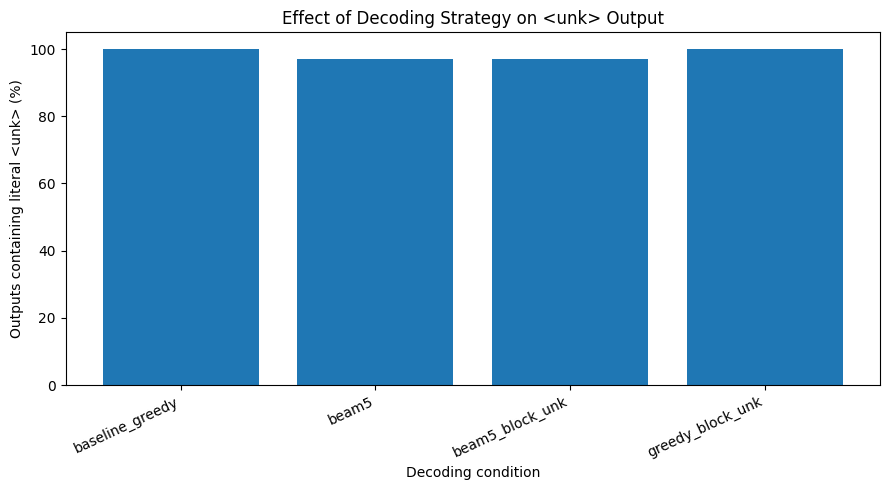

In [13]:
unk_summary = (
    results.groupby("experiment")
    .agg(
        clips=("id", "size"),
        clips_with_literal_unk=(
            "decoded_contains_literal_unk",
            "sum",
        ),
        generated_unk_ids=(
            "generated_unk_id_count",
            "sum",
        ),
        mean_runtime_sec=("runtime_sec", "mean"),
        median_runtime_sec=("runtime_sec", "median"),
    )
    .reset_index()
)

unk_summary["literal_unk_rate_pct"] = (
    100
    * unk_summary["clips_with_literal_unk"]
    / unk_summary["clips"]
)

display(unk_summary)

unk_summary.to_csv(
    OUTPUT_DIR / "unk_rate_by_condition.csv",
    index=False,
)

plt.figure(figsize=(9, 5))
plt.bar(
    unk_summary["experiment"],
    unk_summary["literal_unk_rate_pct"],
)
plt.ylabel("Outputs containing literal <unk> (%)")
plt.xlabel("Decoding condition")
plt.title("Effect of Decoding Strategy on <unk> Output")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 13. Translation metrics on the same subset

All four conditions are compared on exactly the same reference translations.


In [14]:
from sacrebleu.metrics import BLEU, CHRF

bleu_metric = BLEU(tokenize="zh")
chrf_metric = CHRF(beta=2, word_order=0)
chrfpp_metric = CHRF(beta=2, word_order=2)

metric_rows = []

for experiment_name, group in results.groupby("experiment", sort=False):
    hypotheses = group["translation"].astype(str).tolist()
    references = group["reference_translation_zh"].astype(str).tolist()

    metric_rows.append({
        "experiment": experiment_name,
        "n": len(group),
        "BLEU_zh": bleu_metric.corpus_score(
            hypotheses,
            [references],
        ).score,
        "chrF": chrf_metric.corpus_score(
            hypotheses,
            [references],
        ).score,
        "chrFpp": chrfpp_metric.corpus_score(
            hypotheses,
            [references],
        ).score,
        "literal_unk_outputs": int(
            group["decoded_contains_literal_unk"].sum()
        ),
    })

metric_summary = pd.DataFrame(metric_rows)

display(metric_summary)

metric_summary.to_csv(
    OUTPUT_DIR / "translation_metrics_by_condition.csv",
    index=False,
)

print("BLEU signature:", bleu_metric.get_signature())
print("chrF signature:", chrf_metric.get_signature())
print("chrF++ signature:", chrfpp_metric.get_signature())


,experiment,n,BLEU_zh,chrF,chrFpp,literal_unk_outputs
0,baseline_greedy,35,28.186585,24.850456,18.863623,35
1,greedy_block_unk,35,28.186585,24.850456,18.863623,35
2,beam5,35,29.108336,25.627272,19.446038,34
3,beam5_block_unk,35,29.108336,25.627272,19.446038,34


BLEU signature: nrefs:1|case:mixed|eff:no|tok:zh|smooth:exp|version:2.6.0
chrF signature: nrefs:1|case:mixed|eff:yes|nc:6|nw:0|space:no|version:2.6.0
chrF++ signature: nrefs:1|case:mixed|eff:yes|nc:6|nw:2|space:no|version:2.6.0


## 14. Side-by-side output inspection

Blocking `<unk>` forces the decoder to choose something else. That replacement is **not automatically correct**, so manual inspection is essential.


In [15]:
comparison = (
    results.pivot_table(
        index=[
            "id",
            "primary_accent",
            "sentence",
            "reference_translation_zh",
            "official_direct_translation",
        ],
        columns="experiment",
        values="translation",
        aggfunc="first",
    )
    .reset_index()
)

display(comparison.head(50))

comparison.to_csv(
    OUTPUT_DIR / "side_by_side_outputs.csv",
    index=False,
    encoding="utf-8-sig",
)


experiment,id,primary_accent,sentence,reference_translation_zh,official_direct_translation,baseline_greedy,beam5,beam5_block_unk,greedy_block_unk
0,sample_0090,England English,Restoration silver is characterized by embosse...,修复银的特点是压花图案表现的郁金香和自然的水果和树叶。,修复银的特点是<unk>花和自然的水果和叶子的雕刻图案.,修复银的特点是<unk>花和自然的水果和叶子的雕刻图案.,修复银的特点是郁金香和自然的水果和叶子的雕刻图案.,修复银的特点是郁金香和自然的水果和叶子的雕刻图案.,修复银的特点是<unk>花和自然的水果和叶子的雕刻图案.
1,sample_0221,England English,Who is the blonde girl with the red skirt?,那个穿红裙子的金发女孩是谁?,那个穿着红色<unk>子的金发女孩是谁?,那个穿着红色<unk>子的金发女孩是谁?,那个穿着红色<unk>子的金发女孩是谁?,那个穿着红色<unk>子的金发女孩是谁?,那个穿着红色<unk>子的金发女孩是谁?
2,sample_0235,England English,"When he saw Henderson in his garden, he called...",当他看见 Henderson 在他的花园里时，他隔着篱笆喊了一声，对方明白了他的意思。,"当他看到亨德森在他的花园,他叫过<unk>,并让自己理解.","当他看到亨德森在他的花园,他叫过<unk>,并让自己理解.","当他看到亨德森在他的花园,他叫过围<unk>和让自己理解.","当他看到亨德森在他的花园,他叫过围<unk>和让自己理解.","当他看到亨德森在他的花园,他叫过<unk>,并让自己理解."
3,sample_0282,England English,The hail pattered on the burnt brown grass.,冰雹拍打着烧焦的棕色草地。,冰雹在烧焦的棕色草地上<unk>.,冰雹在烧焦的棕色草地上<unk>.,冰<unk>在烧焦的棕色草地上<unk>.,冰<unk>在烧焦的棕色草地上<unk>.,冰雹在烧焦的棕色草地上<unk>.
4,sample_0441,England English,"Roll the dice, please.",请掷骰子。,"投<unk>子,请.","投<unk>子,请.","投<unk>子,请.","投<unk>子,请.","投<unk>子,请."
5,sample_0653,Filipino,"Grime, rust and residual particles polluted th...",尘垢、铁锈和残留的微粒污染了空气。,"污垢,<unk>和残留的粒子污染了空气.","污垢,<unk>和残留的粒子污染了空气.","污垢,<unk>和残留的粒子污染了空气.","污垢,<unk>和残留的粒子污染了空气.","污垢,<unk>和残留的粒子污染了空气."
6,sample_0731,Filipino,A little scrambling is required for access.,访问需要加一些扰码。,需要一点<unk>密才能进入.,需要一点<unk>密才能进入.,需要稍微<unk>密才能访问.,需要稍微<unk>密才能访问.,需要一点<unk>密才能进入.
7,sample_0826,Filipino,"The Englishman prodded him, and the boy asked ...",英国人戳了他一下，男孩就问她是谁治好了人们的病。,"这位英国人<unk>了他,男孩问她关于治愈人们疾病的人.","这位英国人<unk>了他,男孩问她关于治愈人们疾病的人.","这位英国人<unk>了他,男孩问她关于治愈人们疾病的人.","这位英国人<unk>了他,男孩问她关于治愈人们疾病的人.","这位英国人<unk>了他,男孩问她关于治愈人们疾病的人."
8,sample_0905,Filipino,"They walked in from the rain, all dishevelled ...",他们从雨中走了进来，衣冠不整，浑身湿透。,"他们从雨中走进来, 所有的<unk>乱和蒸汽.","他们从雨中走进来, 所有的<unk>乱和蒸汽.","他们从雨中走进来, 所有的<unk>乱和蒸汽.","他们从雨中走进来, 所有的<unk>乱和蒸汽.","他们从雨中走进来, 所有的<unk>乱和蒸汽."
9,sample_0965,Filipino,"You were looking squeamish this afternoon, he ...",他说着，你今天下午看起来很邋遢。,"他开始说,今天下午你看起来很<unk>.","他开始说,你今天下午看起来很<unk>.","你今天下午看起来很<unk>,他开始.","你今天下午看起来很<unk>,他开始.","他开始说,你今天下午看起来很<unk>."


## 15. Cases where greedy UNK blocking removes `<unk>`


In [16]:
greedy_base = results[
    results["experiment"] == "baseline_greedy"
][
    ["id", "translation", "decoded_contains_literal_unk"]
].rename(
    columns={
        "translation": "baseline_translation",
        "decoded_contains_literal_unk": "baseline_has_unk",
    }
)

greedy_blocked = results[
    results["experiment"] == "greedy_block_unk"
][
    ["id", "translation", "decoded_contains_literal_unk"]
].rename(
    columns={
        "translation": "blocked_translation",
        "decoded_contains_literal_unk": "blocked_has_unk",
    }
)

removed = greedy_base.merge(
    greedy_blocked,
    on="id",
    validate="one_to_one",
)

removed["unk_removed"] = (
    removed["baseline_has_unk"]
    & ~removed["blocked_has_unk"]
)

removed = removed.merge(
    test_df[
        [
            "id",
            "sentence",
            "reference_translation_zh",
            "primary_accent",
        ]
    ],
    on="id",
    validate="one_to_one",
)

print(
    "Greedy clips where <unk> was removed:",
    int(removed["unk_removed"].sum()),
    "/",
    len(removed),
)

display(
    removed[
        removed["unk_removed"]
    ][
        [
            "id",
            "primary_accent",
            "sentence",
            "reference_translation_zh",
            "baseline_translation",
            "blocked_translation",
        ]
    ].head(50)
)

removed.to_csv(
    OUTPUT_DIR / "greedy_unk_blocking_changes.csv",
    index=False,
    encoding="utf-8-sig",
)


Greedy clips where <unk> was removed: 0 / 35


,id,primary_accent,sentence,reference_translation_zh,baseline_translation,blocked_translation


## 16. Save reproducibility summary


In [17]:
run_summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "test_scope": TEST_SCOPE,
    "samples_per_accent": (
        SAMPLES_PER_ACCENT
        if TEST_SCOPE == "balanced_small"
        else None
    ),
    "number_of_selected_clips": int(len(test_df)),
    "original_affected_rows_total": int(len(affected)),
    "model_id": MODEL_ID,
    "model_revision": MODEL_REVISION,
    "target_language": TARGET_LANGUAGE,
    "device": str(DEVICE),
    "dtype": str(MODEL_DTYPE),
    "gpu": GPU_NAME,
    "pytorch_version": torch.__version__,
    "torchaudio_version": torchaudio.__version__,
    "transformers_version": transformers.__version__,
    "sacrebleu_version": sacrebleu.__version__,
    "unk_token": UNK_TOKEN,
    "unk_token_id": UNK_ID,
    "experiments": EXPERIMENTS,
    "baseline_exact_reproduction_rate": float(match_rate),
    "note": (
        "Sensitivity analysis only. Official 4,200-sample Direct "
        "predictions remain unchanged."
    ),
}

(OUTPUT_DIR / "run_summary.json").write_text(
    json.dumps(run_summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print(json.dumps(run_summary, indent=2, ensure_ascii=False))
print("\nSaved to:", OUTPUT_DIR)


{
  "created_utc": "2026-09-21T01:42:03.744326+00:00",
  "test_scope": "balanced_small",
  "samples_per_accent": 5,
  "number_of_selected_clips": 35,
  "original_affected_rows_total": 508,
  "model_id": "facebook/seamless-m4t-v2-large",
  "model_revision": "5f8cc790b19fc3f67a61c105133b20b34e3dcb76",
  "target_language": "cmn",
  "device": "cpu",
  "dtype": "torch.float32",
  "gpu": null,
  "pytorch_version": "2.8.0",
  "torchaudio_version": "2.8.0",
  "transformers_version": "4.57.6",
  "sacrebleu_version": "2.6.0",
  "unk_token": "<unk>",
  "unk_token_id": 1,
  "experiments": {
    "baseline_greedy": {
      "num_beams": 1,
      "do_sample": false,
      "max_new_tokens": 256,
      "block_unk": false
    },
    "greedy_block_unk": {
      "num_beams": 1,
      "do_sample": false,
      "max_new_tokens": 256,
      "block_unk": true
    },
    "beam5": {
      "num_beams": 5,
      "do_sample": false,
      "max_new_tokens": 256,
      "block_unk": false
    },
    "beam5_block_unk":

## Decision guide

- **Greedy + block `<unk>` removes `<unk>` and improves metrics/manual quality:** unknown-token suppression is a useful mitigation.
- **Blocking removes `<unk>` but quality does not improve:** the decoder is choosing another token, not necessarily a better translation.
- **Beam-5 reduces `<unk>`:** the issue is partly sensitive to search strategy.
- **Beam-5 does not reduce `<unk>`:** greedy decoding alone is not the main explanation.
- **Baseline fails to reproduce the official output:** inspect environment differences before interpreting sensitivity results.

Do **not** overwrite the official `direct_predictions.csv`. Any mitigation found after inspecting final results should be reported as a separate sensitivity experiment.
